In [2]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

keras.utils.set_random_seed(42)

DATA_PATH = "/content/drive/MyDrive/DL LAB S2/4/Dataset"
IMG_SIZE = 128
BATCH_SIZE = 16

In [3]:
# =====================================
# LOAD DATA (RGB)
# =====================================

train_ds = keras.utils.image_dataset_from_directory(
    os.path.join(DATA_PATH, "train"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",   # 🔥 RGB NOW
    label_mode="int"
)

test_ds = keras.utils.image_dataset_from_directory(
    os.path.join(DATA_PATH, "test"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="rgb",   # 🔥 RGB NOW
    label_mode="int",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Found 263 files belonging to 3 classes.
Found 154 files belonging to 3 classes.
Classes: ['bag', 'shirt', 'shoe']


In [4]:
# =====================================
# DATA AUGMENTATION (Light)
# =====================================

data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.05),
])

In [5]:
# =====================================
# NORMALIZATION
# =====================================

normalization_layer = keras.layers.Rescaling(1./255)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(
    lambda x, y: (data_augmentation(normalization_layer(x), training=True), y)
).prefetch(AUTOTUNE)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y)
).prefetch(AUTOTUNE)

In [6]:
# =====================================
# MODEL (RGB INPUT)
# =====================================

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))  # 🔥 3 CHANNELS

x = keras.layers.Conv2D(32, (3,3), padding="same", activation="relu")(inputs)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPooling2D()(x)

x = keras.layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPooling2D()(x)

x = keras.layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.MaxPooling2D()(x)

x = keras.layers.GlobalAveragePooling2D()(x)

x = keras.layers.Dense(128, activation="relu")(x)
x = keras.layers.Dropout(0.5)(x)

outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print(model.summary())

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,043 (433.76 KB)

 Trainable params: 110,595 (432.01 KB)

 Non-trainable params: 448 (1.75 KB)

None


In [7]:
# =====================================
# EARLY STOPPING
# =====================================

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [8]:
# =====================================
# TRAIN
# =====================================

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=test_ds,
    callbacks=[early_stop]
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.5932 - loss: 0.8857 - val_accuracy: 0.3701 - val_loss: 1.0996
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7414 - loss: 0.6488 - val_accuracy: 0.5649 - val_loss: 1.0965
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7643 - loss: 0.5704 - val_accuracy: 0.3571 - val_loss: 1.0796
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 19s 962ms/step - accuracy: 0.7871 - loss: 0.5346 - val_accuracy: 0.4351 - val_loss: 1.0718
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7947 - loss: 0.5479 - val_accuracy: 0.3701 - val_loss: 1.0725
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8061 - loss: 0.4793 - val_accuracy: 0.4091 - val_loss: 1.0823
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 950ms/step - accuracy: 0.8479 - loss: 0.4248 - val_accuracy: 0.4286 - val_loss: 1.0451
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 16s 945ms/step - accuracy: 0.8251 - loss: 0.4157 - val_accuracy: 0.2987 - 

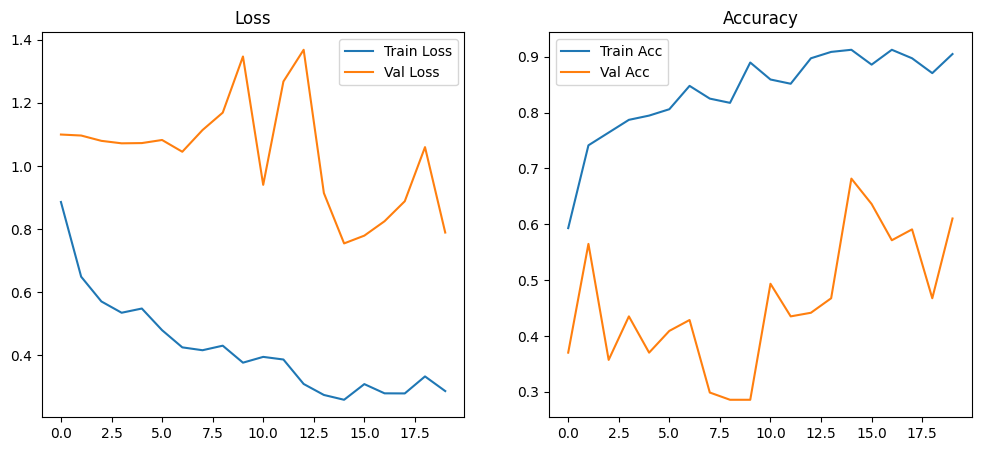

In [9]:
# =====================================
# PLOT TRAINING CURVES
# =====================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.show()

In [10]:
# =====================================
# EVALUATE
# =====================================

test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Accuracy:", test_accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 253ms/step - accuracy: 0.6818 - loss: 0.7544
Test Accuracy: 0.6818181872367859


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step


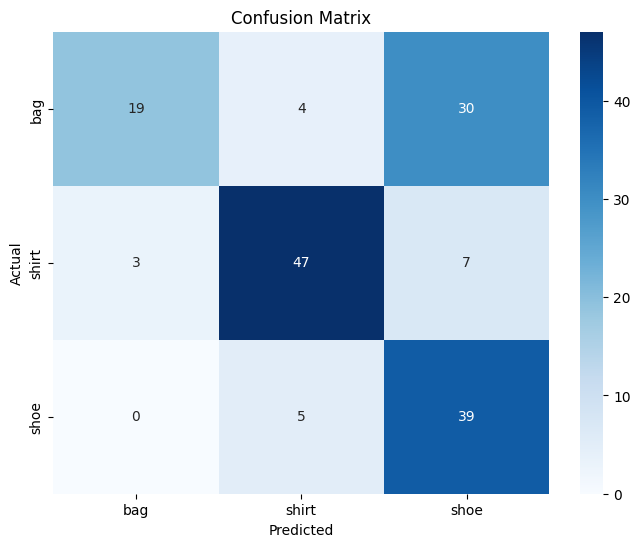

In [11]:
# =====================================
# CONFUSION MATRIX
# =====================================

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
# =====================================
# SAVE MODEL
# =====================================

model.save("custom_model_rgb.keras")

print("RGB Model Saved Successfully!")

RGB Model Saved Successfully!
